In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [12]:
df = pd.read_csv("../Data/farmer_scoring_sample_yogyank_round1.csv")

In [13]:
df.head()

,farmer_id,application_year,district,land_area_acres,crop_type,pm_kisan_status,historical_repayment_score,irrigation_type,land_ownership,soil_type,sales_channel,annual_income_inr,liability_ratio_pct,rainfall_deviation_pct,ndvi_score,defaulted_in_next_12_months,target_entitlement_score
0,F00001,2023,Cuttack,16.71,Soybean,Yes,59.77,Irrigated,Owned,Black,APMC,377500.53,41.14,-13.64,0.466,0,689.88
1,F00002,2022,Puri,11.72,Wheat,Yes,60.84,Rainfed,Owned,Alluvial,FPO,384595.39,5.51,NaN,0.500,0,810.97
2,F00003,2023,Puri,10.44,Soybean,Yes,54.06,Rainfed,Owned,Laterite,Contract Buyer,223024.07,2.93,-9.77,0.789,0,845.49
3,F00004,2023,Mayurbhanj,6.72,Cotton,Yes,45.04,Irrigated,Owned,Clay Loam,Local Trader,417534.25,20.08,32.19,NaN,0,690.40
4,F00005,2023,Ganjam,11.28,Wheat,No,57.73,Irrigated,Owned,Laterite,Local Trader,206349.85,8.80,0.51,0.560,0,798.32


In [14]:
df.shape

(5000, 17)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   farmer_id                    5000 non-null   object 
 1   application_year             5000 non-null   int64  
 2   district                     5000 non-null   object 
 3   land_area_acres              5000 non-null   float64
 4   crop_type                    5000 non-null   object 
 5   pm_kisan_status              5000 non-null   object 
 6   historical_repayment_score   5000 non-null   float64
 7   irrigation_type              5000 non-null   object 
 8   land_ownership               5000 non-null   object 
 9   soil_type                    5000 non-null   object 
 10  sales_channel                5000 non-null   object 
 11  annual_income_inr            5000 non-null   float64
 12  liability_ratio_pct          5000 non-null   float64
 13  rainfall_deviation

In [17]:
df.columns

Index(['farmer_id', 'application_year', 'district', 'land_area_acres',
       'crop_type', 'pm_kisan_status', 'historical_repayment_score',
       'irrigation_type', 'land_ownership', 'soil_type', 'sales_channel',
       'annual_income_inr', 'liability_ratio_pct', 'rainfall_deviation_pct',
       'ndvi_score', 'defaulted_in_next_12_months',
       'target_entitlement_score'],
      dtype='object')

In [18]:
df.isnull().sum()

farmer_id                        0
application_year                 0
district                         0
land_area_acres                  0
crop_type                        0
pm_kisan_status                  0
historical_repayment_score       0
irrigation_type                  0
land_ownership                   0
soil_type                        0
sales_channel                    0
annual_income_inr                0
liability_ratio_pct              0
rainfall_deviation_pct         750
ndvi_score                     750
defaulted_in_next_12_months      0
target_entitlement_score         0
dtype: int64

In [20]:
df['target_entitlement_score'].describe()

count    5000.000000
mean      765.834234
std       105.574818
min       421.760000
25%       694.122500
50%       766.130000
75%       840.330000
max       980.000000
Name: target_entitlement_score, dtype: float64

<Axes: >

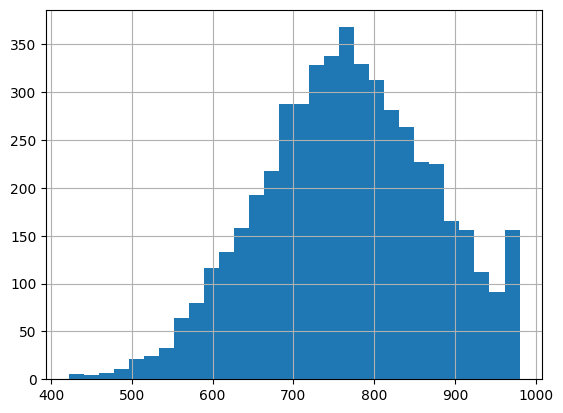

In [24]:
df['target_entitlement_score'].hist(bins=30)

## Observation
1. Shape is (5000, 12)
2. There are two columns with missing values 
(rainfall_deviation_pct, ndvi_score)
3. Target distribution normal


In [ ]:
# Checking data distribution and balancy of target column
target_col = "defaulted_in_next_12_months"

In [25]:
df.head()

,farmer_id,application_year,district,land_area_acres,crop_type,pm_kisan_status,historical_repayment_score,irrigation_type,land_ownership,soil_type,sales_channel,annual_income_inr,liability_ratio_pct,rainfall_deviation_pct,ndvi_score,defaulted_in_next_12_months,target_entitlement_score
0,F00001,2023,Cuttack,16.71,Soybean,Yes,59.77,Irrigated,Owned,Black,APMC,377500.53,41.14,-13.64,0.466,0,689.88
1,F00002,2022,Puri,11.72,Wheat,Yes,60.84,Rainfed,Owned,Alluvial,FPO,384595.39,5.51,NaN,0.500,0,810.97
2,F00003,2023,Puri,10.44,Soybean,Yes,54.06,Rainfed,Owned,Laterite,Contract Buyer,223024.07,2.93,-9.77,0.789,0,845.49
3,F00004,2023,Mayurbhanj,6.72,Cotton,Yes,45.04,Irrigated,Owned,Clay Loam,Local Trader,417534.25,20.08,32.19,NaN,0,690.40
4,F00005,2023,Ganjam,11.28,Wheat,No,57.73,Irrigated,Owned,Laterite,Local Trader,206349.85,8.80,0.51,0.560,0,798.32


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   farmer_id                    5000 non-null   object 
 1   application_year             5000 non-null   int64  
 2   district                     5000 non-null   object 
 3   land_area_acres              5000 non-null   float64
 4   crop_type                    5000 non-null   object 
 5   pm_kisan_status              5000 non-null   object 
 6   historical_repayment_score   5000 non-null   float64
 7   irrigation_type              5000 non-null   object 
 8   land_ownership               5000 non-null   object 
 9   soil_type                    5000 non-null   object 
 10  sales_channel                5000 non-null   object 
 11  annual_income_inr            5000 non-null   float64
 12  liability_ratio_pct          5000 non-null   float64
 13  rainfall_deviation

In [28]:
print(df.columns.tolist())

['farmer_id', 'application_year', 'district', 'land_area_acres', 'crop_type', 'pm_kisan_status', 'historical_repayment_score', 'irrigation_type', 'land_ownership', 'soil_type', 'sales_channel', 'annual_income_inr', 'liability_ratio_pct', 'rainfall_deviation_pct', 'ndvi_score', 'defaulted_in_next_12_months', 'target_entitlement_score']


In [29]:
# Defining dependent and independent features
TARGET = "target_entitlement_score"

In [30]:
NON_FEATURE_COLS = [
    "farmer_id",
    "defaulted_in_next_12_months",
    TARGET
]

In [31]:
X = df.drop(columns=NON_FEATURE_COLS)
y = df[TARGET]

In [32]:
print(X.shape)
print(y.shape)

(5000, 14)
(5000,)


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [36]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

In [37]:
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['application_year', 'land_area_acres', 'historical_repayment_score', 'annual_income_inr', 'liability_ratio_pct', 'rainfall_deviation_pct', 'ndvi_score']
Categorical: ['district', 'crop_type', 'pm_kisan_status', 'irrigation_type', 'land_ownership', 'soil_type', 'sales_channel']


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# Preprocessor pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [40]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [41]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [42]:
# pipeline run
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [44]:
# model traine with existing parameter (later hyper parameter tuning)
model = GradientBoostingRegressor(
    n_estimators=60,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,60
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [45]:
preds = model.predict(X_test_processed)